In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

In [2]:
raw_train_data_path = "train_data.csv"
raw_test_data_path = "test_data.csv"

train_dataset = pd.read_csv(raw_train_data_path)
test_dataset = pd.read_csv(raw_test_data_path)

datasets = {"train": train_dataset, "test": test_dataset}


datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,141592,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0
1,51327,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
2,48672,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
3,380530,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0
4,78318,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796,2007,1928,24,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0
4120,307079,2015,644,22,terraced,individual_heating,management_in_trust,102.0,400.0,0~5min,5min~10min,5.0,10.0,Daegu,7,7.0,11.0
4121,357522,2007,868,20,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0
4122,312389,1978,1327,1,corridor,individual_heating,self_management,87.0,0.0,0~5min,0-5min,1.0,4.0,Kyungbuk_uni_hospital,3,7.0,11.0


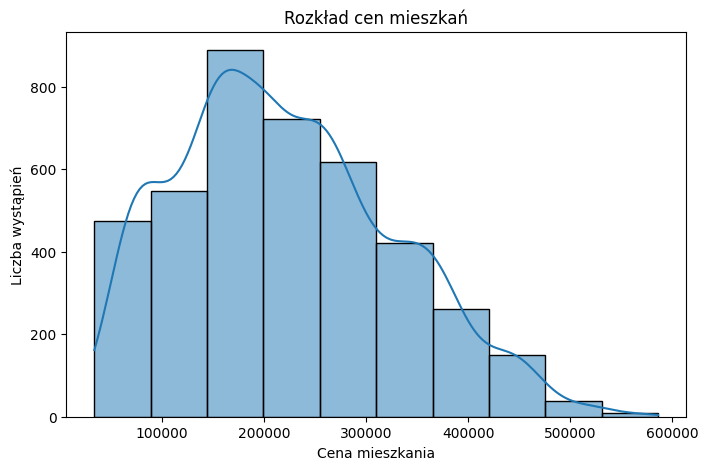

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(train_dataset["SalePrice"], bins=10, kde=True)
plt.xlabel("Cena mieszkania")
plt.ylabel("Liczba wystąpień")
plt.title("Rozkład cen mieszkań")
plt.show()

In [4]:
def classify_price(price: int):
    if price <= 100000:
        return "cheap"
    elif price <= 350000:
        return "average"
    else:
        return "expensive"


train_dataset["PriceCategory"] = train_dataset["SalePrice"].apply(classify_price)
train_dataset["PriceCategoryNum"] = train_dataset["PriceCategory"].map(
    {"cheap": 0.0, "average": 1.0, "expensive": 2.0}
)

train_dataset

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0,average,1.0
1,51327,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0,cheap,0.0
2,48672,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0,cheap,0.0
3,380530,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0,expensive,2.0
4,78318,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796,2007,1928,24,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0,expensive,2.0
4120,307079,2015,644,22,terraced,individual_heating,management_in_trust,102.0,400.0,0~5min,5min~10min,5.0,10.0,Daegu,7,7.0,11.0,average,1.0
4121,357522,2007,868,20,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0,expensive,2.0
4122,312389,1978,1327,1,corridor,individual_heating,self_management,87.0,0.0,0~5min,0-5min,1.0,4.0,Kyungbuk_uni_hospital,3,7.0,11.0,average,1.0


/var/folders/rh/8hh2vd4j4xzcvyl1kj3kzf600000gn/T/ipykernel_85374/2715099235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


Text(0.5, 1.0, 'Liczba wystąpień każdej klasy cenowej')

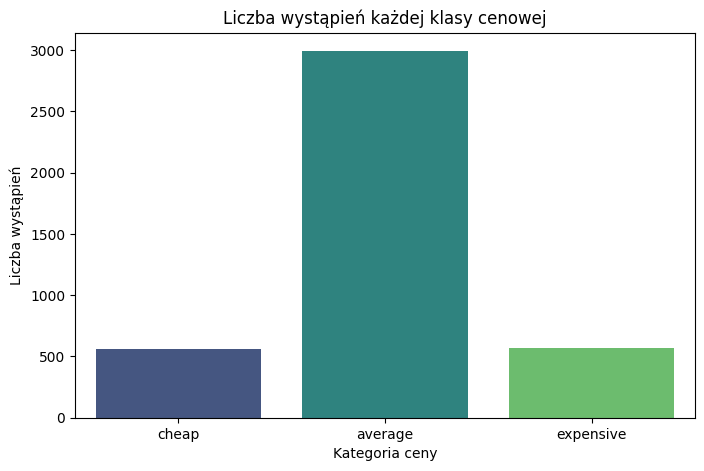

In [5]:
order = ["cheap", "average", "expensive"]
class_counts = train_dataset["PriceCategory"].value_counts()[order]

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


plt.xlabel("Kategoria ceny")
plt.ylabel("Liczba wystąpień")
plt.title("Liczba wystąpień każdej klasy cenowej")

In [6]:
for key, dataset in datasets.items():
    datasets[key] = dataset.map(lambda x: float(x) if isinstance(x, int) else x)

In [7]:
unique_categorical_values = train_dataset.select_dtypes(include=["object"]).nunique()
unique_categorical_values

HallwayType      3
HeatingType      2
AptManageType    2
TimeToBusStop    3
TimeToSubway     5
SubwayStation    8
PriceCategory    3
dtype: int64

In [8]:
datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592.0,2006.0,814.0,3.0,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5.0,6.0,9.0,average,1.0
1,51327.0,1985.0,587.0,8.0,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
2,48672.0,1985.0,587.0,6.0,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
3,380530.0,2006.0,2056.0,8.0,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5.0,3.0,7.0,expensive,2.0
4,78318.0,1992.0,644.0,2.0,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3.0,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4120,307079.0,2015.0,644.0,22.0,terraced,individual_heating,management_in_trust,102.0,400.0,0~5min,5min~10min,5.0,10.0,Daegu,7.0,7.0,11.0,average,1.0
4121,357522.0,2007.0,868.0,20.0,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4122,312389.0,1978.0,1327.0,1.0,corridor,individual_heating,self_management,87.0,0.0,0~5min,0-5min,1.0,4.0,Kyungbuk_uni_hospital,3.0,7.0,11.0,average,1.0


In [9]:
def convert_time_to_avg(time_range: str):
    try:
        parts = time_range.replace("min", "").replace("-", "~").split("~")
        lower, upper = map(int, parts)
        return (lower + upper) / 2
    except Exception:
        return np.nan

In [10]:
for dataset in datasets.values():
    dataset["TimeToBusStop"] = dataset["TimeToBusStop"].apply(convert_time_to_avg)
    dataset["TimeToSubway"] = dataset["TimeToSubway"].apply(convert_time_to_avg)

datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592.0,2006.0,814.0,3.0,terraced,individual_heating,management_in_trust,111.0,184.0,7.5,12.5,3.0,0.0,Kyungbuk_uni_hospital,5.0,6.0,9.0,average,1.0
1,51327.0,1985.0,587.0,8.0,corridor,individual_heating,self_management,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
2,48672.0,1985.0,587.0,6.0,corridor,individual_heating,self_management,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
3,380530.0,2006.0,2056.0,8.0,terraced,individual_heating,management_in_trust,249.0,536.0,2.5,2.5,5.0,11.0,Sin-nam,5.0,3.0,7.0,expensive,2.0
4,78318.0,1992.0,644.0,2.0,mixed,individual_heating,self_management,142.0,79.0,7.5,17.5,4.0,8.0,Myung-duk,3.0,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,terraced,individual_heating,management_in_trust,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4120,307079.0,2015.0,644.0,22.0,terraced,individual_heating,management_in_trust,102.0,400.0,2.5,7.5,5.0,10.0,Daegu,7.0,7.0,11.0,average,1.0
4121,357522.0,2007.0,868.0,20.0,terraced,individual_heating,management_in_trust,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4122,312389.0,1978.0,1327.0,1.0,corridor,individual_heating,self_management,87.0,0.0,2.5,2.5,1.0,4.0,Kyungbuk_uni_hospital,3.0,7.0,11.0,average,1.0


In [11]:
max_bus_time = max(dataset["TimeToBusStop"].max() for dataset in datasets.values())
max_subway_time = max(dataset["TimeToSubway"].max() for dataset in datasets.values())

for dataset in datasets.values():
    dataset["TimeToBusStop"] = dataset["TimeToBusStop"].fillna(2 * max_bus_time)
    dataset["TimeToSubway"] = dataset["TimeToSubway"].fillna(2 * max_subway_time)

datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592.0,2006.0,814.0,3.0,terraced,individual_heating,management_in_trust,111.0,184.0,7.5,12.5,3.0,0.0,Kyungbuk_uni_hospital,5.0,6.0,9.0,average,1.0
1,51327.0,1985.0,587.0,8.0,corridor,individual_heating,self_management,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
2,48672.0,1985.0,587.0,6.0,corridor,individual_heating,self_management,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
3,380530.0,2006.0,2056.0,8.0,terraced,individual_heating,management_in_trust,249.0,536.0,2.5,2.5,5.0,11.0,Sin-nam,5.0,3.0,7.0,expensive,2.0
4,78318.0,1992.0,644.0,2.0,mixed,individual_heating,self_management,142.0,79.0,7.5,17.5,4.0,8.0,Myung-duk,3.0,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,terraced,individual_heating,management_in_trust,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4120,307079.0,2015.0,644.0,22.0,terraced,individual_heating,management_in_trust,102.0,400.0,2.5,7.5,5.0,10.0,Daegu,7.0,7.0,11.0,average,1.0
4121,357522.0,2007.0,868.0,20.0,terraced,individual_heating,management_in_trust,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4122,312389.0,1978.0,1327.0,1.0,corridor,individual_heating,self_management,87.0,0.0,2.5,2.5,1.0,4.0,Kyungbuk_uni_hospital,3.0,7.0,11.0,average,1.0


In [12]:
unique_categorical_values = (
    datasets["train"].select_dtypes(include=["object"]).nunique()
)
unique_categorical_values

HallwayType      3
HeatingType      2
AptManageType    2
SubwayStation    8
PriceCategory    3
dtype: int64

In [13]:
categorical_columns = (
    datasets["train"]
    .select_dtypes(include=["object"])
    .drop("PriceCategory", axis=1)
    .columns.to_list()
)
categorical_columns

['HallwayType', 'HeatingType', 'AptManageType', 'SubwayStation']

In [14]:
for key, dataset in datasets.items():
    datasets[key] = pd.get_dummies(dataset, columns=categorical_columns, dtype=float)

datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,...,AptManageType_management_in_trust,AptManageType_self_management,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby
0,141592.0,2006.0,814.0,3.0,111.0,184.0,7.5,12.5,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,51327.0,1985.0,587.0,8.0,80.0,76.0,2.5,7.5,2.0,2.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,48672.0,1985.0,587.0,6.0,80.0,76.0,2.5,7.5,2.0,2.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,380530.0,2006.0,2056.0,8.0,249.0,536.0,2.5,2.5,5.0,11.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,78318.0,1992.0,644.0,2.0,142.0,79.0,7.5,17.5,4.0,8.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,0.0,1270.0,2.5,2.5,14.0,16.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4120,307079.0,2015.0,644.0,22.0,102.0,400.0,2.5,7.5,5.0,10.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4121,357522.0,2007.0,868.0,20.0,0.0,1270.0,2.5,2.5,14.0,16.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4122,312389.0,1978.0,1327.0,1.0,87.0,0.0,2.5,2.5,1.0,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [15]:
train_dataset = datasets["train"]
cols_to_reorder = ["SalePrice", "PriceCategoryNum", "PriceCategory"]

datasets["train"] = train_dataset[
    [col for col in train_dataset.columns if col not in cols_to_reorder]
    + cols_to_reorder
]

datasets["train"]

,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,N_FacilitiesInApt,...,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,SalePrice,PriceCategoryNum,PriceCategory
0,2006.0,814.0,3.0,111.0,184.0,7.5,12.5,3.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,141592.0,1.0,average
1,1985.0,587.0,8.0,80.0,76.0,2.5,7.5,2.0,2.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,51327.0,0.0,cheap
2,1985.0,587.0,6.0,80.0,76.0,2.5,7.5,2.0,2.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48672.0,0.0,cheap
3,2006.0,2056.0,8.0,249.0,536.0,2.5,2.5,5.0,11.0,5.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,380530.0,2.0,expensive
4,1992.0,644.0,2.0,142.0,79.0,7.5,17.5,4.0,8.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,78318.0,0.0,cheap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,2007.0,1928.0,24.0,0.0,1270.0,2.5,2.5,14.0,16.0,10.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,570796.0,2.0,expensive
4120,2015.0,644.0,22.0,102.0,400.0,2.5,7.5,5.0,10.0,7.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,307079.0,1.0,average
4121,2007.0,868.0,20.0,0.0,1270.0,2.5,2.5,14.0,16.0,10.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,357522.0,2.0,expensive
4122,1978.0,1327.0,1.0,87.0,0.0,2.5,2.5,1.0,4.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,312389.0,1.0,average


In [16]:
for key, dataset in datasets.items():
    dataset.to_csv(f"{key}_dataset.csv", index=False)

In [17]:
datasets["train"].describe()

,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,N_FacilitiesInApt,...,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,SalePrice,PriceCategoryNum
count,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,...,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000
mean,2002.977934,959.958778,11.994665,192.789040,572.857662,3.729389,8.508729,6.313773,11.055771,5.824200,...,0.124151,0.128758,0.020611,0.015034,0.272793,0.258244,0.113482,0.066925,222177.477207,1.001940
std,8.765838,384.548456,7.581330,215.455916,408.179957,2.257765,7.789660,3.224556,7.717030,2.344331,...,0.329794,0.334973,0.142096,0.121703,0.445450,0.437722,0.317220,0.249923,106325.535526,0.523979
min,1978.000000,135.000000,1.000000,0.000000,0.000000,2.500000,2.500000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34070.000000,0.000000
25%,1993.000000,644.000000,6.000000,11.000000,184.000000,2.500000,2.500000,5.000000,5.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,144752.000000,1.000000
50%,2006.000000,910.000000,11.000000,100.000000,536.000000,2.500000,7.500000,6.000000,11.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,209588.000000,1.000000
75%,2007.000000,1160.000000,17.000000,249.000000,798.000000,2.500000,12.500000,8.000000,16.000000,7.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,291570.000000,1.000000
max,2015.000000,2337.000000,43.000000,713.000000,1321.000000,12.500000,35.000000,14.000000,27.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,585840.000000,2.000000


In [18]:
from sklearn.preprocessing import StandardScaler

features_scaler = StandardScaler()
sale_price_scaler = StandardScaler()

for key, dataset in datasets.items():
    dataset.loc[:, :"N_SchoolNearBy(Total)"] = features_scaler.fit_transform(
        dataset.loc[:, :"N_SchoolNearBy(Total)"]
    )

datasets["train"]["SalePrice"] = sale_price_scaler.fit_transform(
    datasets["train"][["SalePrice"]]
)


In [19]:
datasets["test"].describe()

,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,N_FacilitiesInApt,...,AptManageType_management_in_trust,AptManageType_self_management,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby
count,1.767000e+03,1.767000e+03,1.767000e+03,1.767000e+03,1.767000e+03,1.767000e+03,1.767000e+03,1.767000e+03,1.767000e+03,1.767000e+03,...,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000
mean,6.240371e-15,4.825418e-17,-9.047658e-17,7.841304e-17,9.650835e-17,-1.135984e-16,-4.423299e-17,2.010591e-17,7.439185e-17,-1.950273e-16,...,0.946802,0.053198,0.127334,0.122807,0.016978,0.013016,0.293718,0.250141,0.103565,0.072439
std,1.000283e+00,1.000283e+00,1.000283e+00,1.000283e+00,1.000283e+00,1.000283e+00,1.000283e+00,1.000283e+00,1.000283e+00,1.000283e+00,...,0.224491,0.224491,0.333442,0.328308,0.129225,0.113377,0.455593,0.433217,0.304782,0.259287
min,-2.796905e+00,-2.147367e+00,-1.485642e+00,-9.003241e-01,-1.381495e+00,-5.335273e-01,-7.973265e-01,-1.736681e+00,-1.418405e+00,-2.077521e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.114917e+00,-7.985123e-01,-8.164441e-01,-8.515635e-01,-9.322840e-01,-5.335273e-01,-7.973265e-01,-4.265239e-01,-7.939166e-01,-7.723611e-01,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.428072e-01,-9.360969e-02,-1.472463e-01,-4.570458e-01,-7.292320e-02,-5.335273e-01,-1.560539e-01,-9.898468e-02,-4.453058e-02,-3.373078e-01,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.670723e-01,4.920425e-01,6.557912e-01,2.034389e-01,5.667147e-01,-5.335273e-01,4.852187e-01,5.560937e-01,5.799578e-01,5.327986e-01,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.000000
max,1.352000e+00,3.687954e+00,4.001781e+00,2.260250e+00,1.843549e+00,3.923885e+00,3.370946e+00,2.521329e+00,1.953832e+00,1.837958e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
joblib.dump(features_scaler, "features_scaler.pkl")
joblib.dump(sale_price_scaler, "sale_price_scaler.pkl")

['sale_price_scaler.pkl']